In [2]:
#importing the libraries along with other that is being used in these 
import yfinance as yf
import mplfinance as mpf
import pandas as pd
import numpy as np

# Optional: Set pandas display options for cleaner notebook outputs
pd.set_option('display.max_columns', None)

In [3]:
#This cell covers the two main ways to get data: investigating a specific company using Ticker, and bulk-downloading price data.
ticker_symbol = 'INFY'
start_date = '2025-01-01' # you can use datetime library as well for defining dates 
end_date = '2025-03-31'

# METHOD A: The Ticker Object (Great for fundamentals, dividends, and info)
stock = yf.Ticker(ticker_symbol)
print(f"Sector: {stock.info.get('sector')}")
print(f"Current Price: {stock.info.get('currentPrice')}")

# METHOD B: Bulk Download (Best for charting and technical analysis)
df = yf.download(ticker_symbol, start=start_date, end=end_date)

# CRUCIAL FIX: yfinance recently updated to use Multi-Index columns. 
# This drops the top level so 'Close', 'Volume', etc., are easy to access!
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

df.head()

Sector: Technology
Current Price: 10.57


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-01-02,21.509607,21.699788,21.385988,21.633225,6556200
2025-01-03,21.519115,21.547643,21.347953,21.414516,3810700
2025-01-06,21.633224,21.690279,21.471570,21.471570,4862600
2025-01-07,21.500097,21.756842,21.424024,21.557151,5150400
2025-01-08,21.661753,21.690279,21.443042,21.481079,6199700


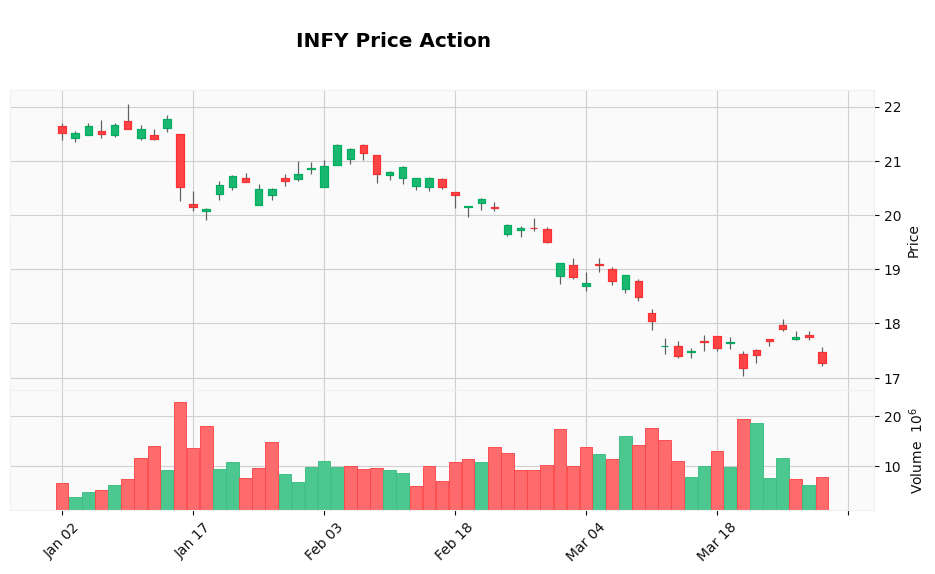

In [4]:
#Basic Charting with mplfinance
# The 'type' parameter can be: 'candle', 'ohlc', 'line', 'renko', or 'pnf'
mpf.plot(
    df, 
    type='candle', 
    volume=True,          # Adds the volume subplot at the bottom
    title=f'\n{ticker_symbol} Price Action',
    style='yahoo',        # Built-in styles: 'yahoo', 'charles', 'binance', 'nightclouds' or you can create your own
    figsize=(12, 6)       # Width, Height
)

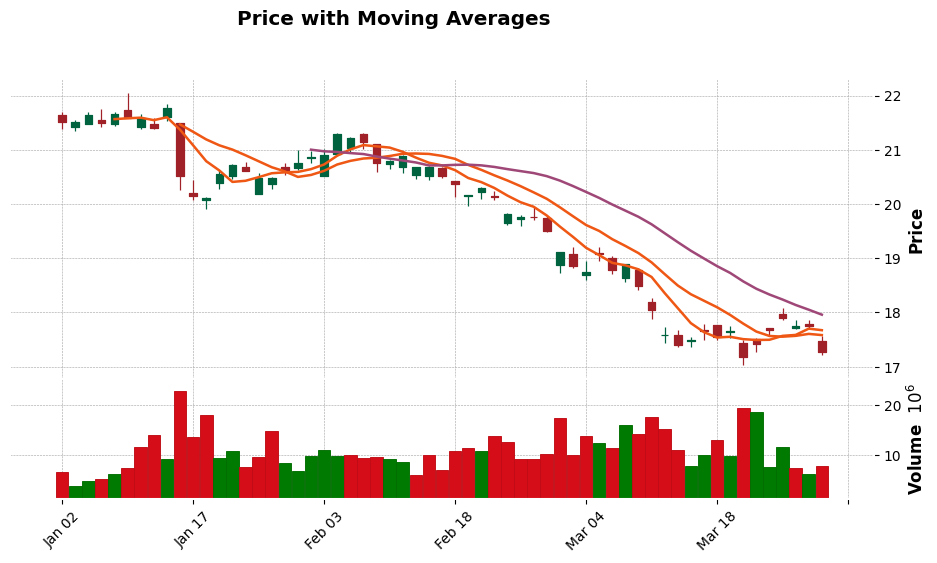

In [5]:
#Moving Averages and formating using mplfinance 
mpf.plot(
    df, 
    type='candle', 
    volume=True,
    mav=(5, 10, 20),      # Automatically calculates and plots 5, 10, and 20 period SMAs!
    show_nontrading=False, # True will show gaps for weekends/holidays
    style='charles',
    title='Price with Moving Averages',
    figsize=(12, 6)
)

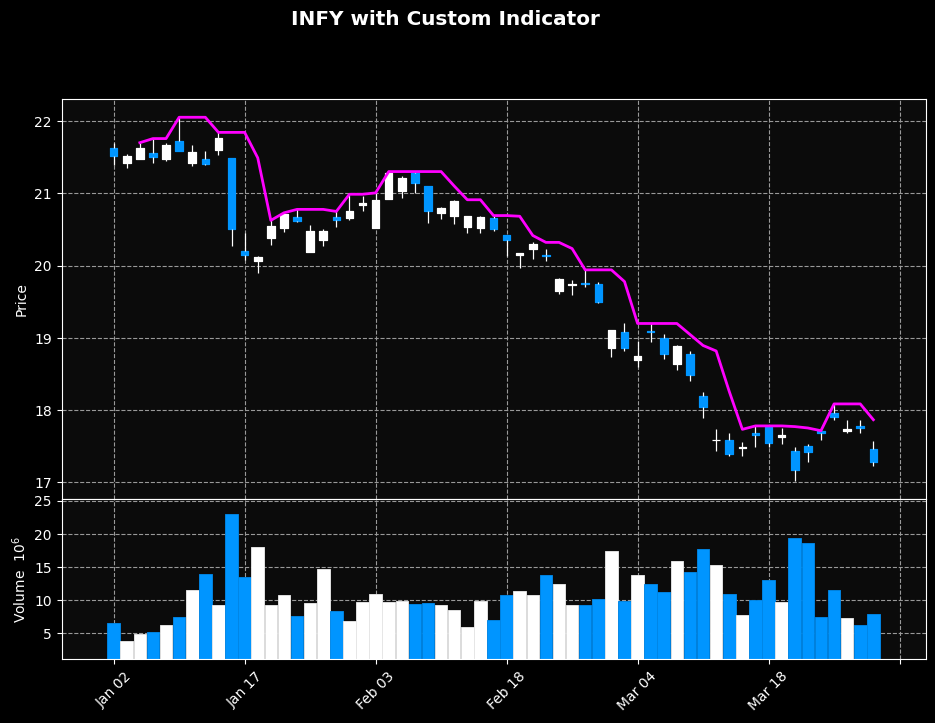

In [6]:
#This is the most important syntax to know if you are building your own financial algorithms. 
# If you calculate a custom indicator (like RSI, MACD, or OBV), you use make_addplot to tell mplfinance how to draw it.

# 1. Create dummy data for a custom indicator (e.g., a rolling 3-day high)
df['Custom_Indicator'] = df['High'].rolling(window=3).max()

# 2. Define the addplot object
# panel=0 puts it on the main price chart. panel=1 puts it on the volume chart. 
# panel=2 creates a brand new chart underneath!
custom_plot = mpf.make_addplot(df['Custom_Indicator'], color='fuchsia', width=2, panel=0)

# 3. Pass the addplot object as a list to the main plot function
mpf.plot(
    df, 
    type='candle', 
    volume=True,
    addplot=[custom_plot], 
    style='nightclouds',
    title=f'{ticker_symbol} with Custom Indicator',
    figsize=(12, 8)
)